# Reintegration & recovery — explanatory + predictive pipeline (IS 455 / CRISP-DM)

**Business question:** Which factors are **most associated** with **successful reintegration** (`reintegration_status = Completed`), and how can we **prioritize** residents who may need more support (decision support — **not** automated decisions)?

**Package:** `ml_pipeline/ml_pipeline_reintegration_effectiveness/`  
**Modular scripts:** `data_prep.py`, `feature_engineering.py`, `train_explanatory.py`, `train_predictive.py`, `evaluate.py`, `export_artifacts.py`, `inference_example.py`

### Predictive vs explanatory (textbook framing)
- **Explanatory:** Logistic regression coefficients / odds ratios describe **associations** conditional on included features — **not causal** effects (no RCT; risk of confounding).
- **Predictive:** Ensemble / tree models + logistic baseline optimize **out-of-sample** ranking; accurate prediction **does not** prove what *caused* recovery.

**Ethics:** Staff-only, authenticated use; human override; do not remove services based solely on scores.

## 1. Environment and imports

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Resolve package: cwd may be repo root, ml_pipeline/, or this package folder
HERE = Path.cwd().resolve()
_candidates = [
    HERE,
    HERE / "ml_pipeline",
    HERE.parent / "ml_pipeline",
    HERE.parent,
]
for p in _candidates:
    if (p / "ml_pipeline_reintegration_effectiveness" / "config.py").is_file():
        sys.path.insert(0, str(p))
        break
else:
    raise RuntimeError(
        "Add WinterIntex4-5/ml_pipeline to path or run Jupyter with cwd under ml_pipeline/"
    )

from ml_pipeline_reintegration_effectiveness import config
from ml_pipeline_reintegration_effectiveness.data_prep import prepare_tables
from ml_pipeline_reintegration_effectiveness.feature_engineering import build_feature_matrix, build_label
from ml_pipeline_reintegration_effectiveness.export_artifacts import export_from_trained_bundle
from ml_pipeline_reintegration_effectiveness.train_explanatory import run_explanatory, split_xy
from ml_pipeline_reintegration_effectiveness.train_predictive import train_predictive_full
from ml_pipeline_reintegration_effectiveness.evaluate import evaluate_pipeline, feature_importance_dataframe

config.OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
config.SERIALIZED_DIR.mkdir(parents=True, exist_ok=True)
print("DATA_DIR:", config.DEFAULT_DATA_DIR)

DATA_DIR: /Users/jooyoung/Downloads/intex2026/WinterIntex4-5/data/lighthouse_csv_v7


## 2. Load tables and define observation date

In [2]:
tables, obs_date = prepare_tables(config.DEFAULT_DATA_DIR)
res = tables["residents"]
print("observation_date:", obs_date)
print(res[["reintegration_status", "case_status"]].value_counts())

observation_date: 2027-02-02 00:00:00
reintegration_status  case_status
On Hold               Active         10
In Progress           Active          9
Completed             Closed          8
                      Active          7
In Progress           Closed          6
                      Transferred     6
Completed             Transferred     4
Not Started           Active          4
                      Closed          3
On Hold               Closed          2
                      Transferred     1
Name: count, dtype: int64


## 3. Target distribution and censoring note

In [3]:
y_raw = build_label(res)
print("Completed rate:", y_raw.mean())
print(y_raw.value_counts())
# Active + In Progress coded 0 — not necessarily failure (censored).
print(res.loc[res["case_status"].eq("Active"), "reintegration_status"].value_counts())

Completed rate: 0.31666666666666665
reintegration_status
0    41
1    19
Name: count, dtype: int64
reintegration_status
On Hold        10
In Progress     9
Completed       7
Not Started     4
Name: count, dtype: int64


## 4. Build leakage-safe feature matrix

In [4]:
X, y, fe_meta = build_feature_matrix(tables, obs_date)
print("X shape:", X.shape)
print(json.dumps({k: fe_meta[k] for k in ("window_start", "window_end", "gap_days", "label_definition")}, indent=2))
X.head()

X shape: (60, 41)
{
  "window_start": "2026-01-03",
  "window_end": "2027-01-03",
  "gap_days": 30,
  "label_definition": "y=1 if reintegration_status=='Completed' on master record; Active/In Progress treated as 0 (censored \u2014 see README)."
}


,resident_id,case_control_no,initial_risk_ord,age_at_admission_years,stay_years_approx,days_in_program_at_window_end,pr_sessions_prior,pr_mean_duration,pr_progress_rate,pr_concern_rate,...,sub_cat_physical_abuse,sub_cat_sexual_abuse,sub_cat_osaec,sub_cat_cicl,sub_cat_at_risk,sub_cat_street_child,sub_cat_child_with_hiv,case_category,initial_case_assessment,region
0,1,C0043,4,15.750000,2.333333,1174.0,7,57.857143,1.0,0.285714,...,0,0,0,0,0,0,0,Neglected,For Reunification,Visayas
1,2,C2530,2,15.416667,1.750000,1387.0,0,0.000000,0.0,0.000000,...,0,0,0,0,1,1,0,Surrendered,For Continued Care,Mindanao
2,3,C3946,2,18.250000,1.750000,954.0,5,80.600000,1.0,0.000000,...,0,1,0,0,0,0,0,Surrendered,For Independent Living,Luzon
3,4,C3116,3,12.916667,1.416667,828.0,9,75.888889,1.0,0.222222,...,0,0,0,1,0,0,0,Neglected,For Reunification,Visayas
4,5,C9132,2,15.333333,0.750000,1089.0,0,0.000000,0.0,0.000000,...,1,0,1,0,0,0,0,Surrendered,For Independent Living,Visayas


## 5. EDA — missingness, numeric distributions, correlations

Top missing rates:
 initial_risk_ord          0.0
age_at_admission_years    0.0
hw_mean_energy            0.0
ip_plans_prior            0.0
ip_achieved_rate          0.0
ip_on_hold_rate           0.0
inc_count_prior           0.0
inc_mean_severity         0.0
sub_cat_orphaned          0.0
sub_cat_trafficked        0.0
dtype: float64


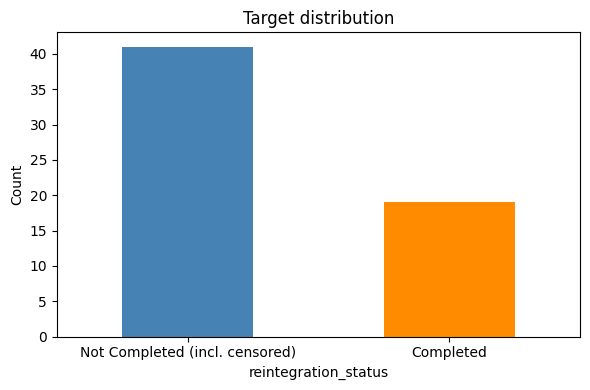

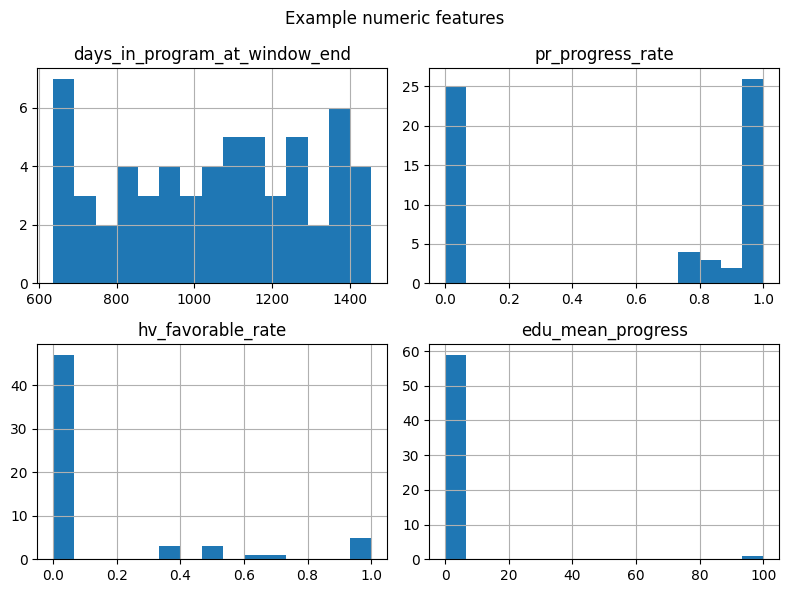

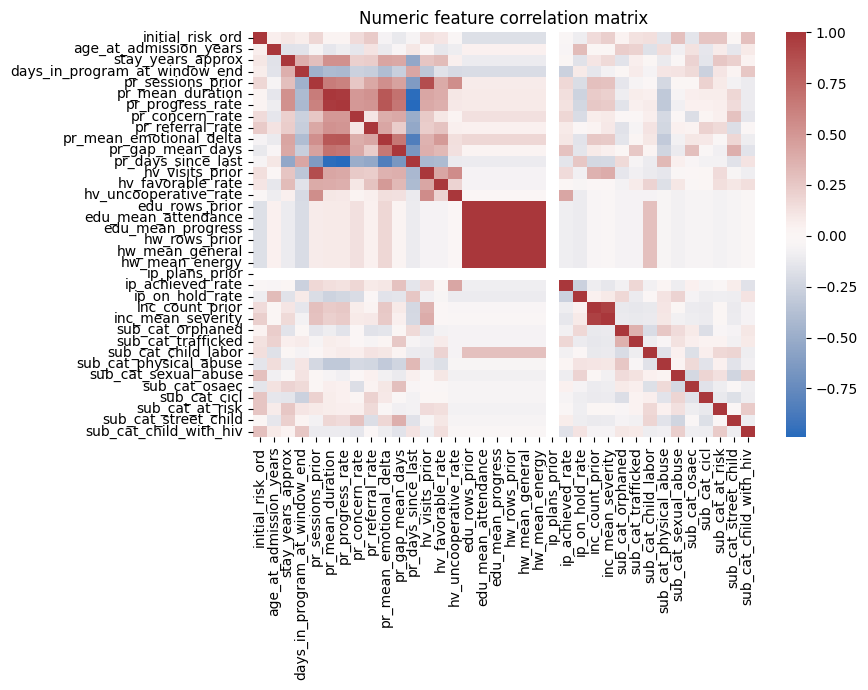

In [5]:
num_cols = fe_meta["numeric_features"]
miss = X[num_cols].isna().mean().sort_values(ascending=False)
print("Top missing rates:\n", miss.head(10))

fig, ax = plt.subplots(figsize=(6, 4))
y.astype(int).value_counts().sort_index().plot(kind="bar", ax=ax, color=["steelblue", "darkorange"])
ax.set_xticklabels(["Not Completed (incl. censored)", "Completed"], rotation=0)
ax.set_title("Target distribution")
ax.set_ylabel("Count")
plt.tight_layout()
fig.savefig(config.OUTPUTS_DIR / "fig_target_distribution.png", dpi=120)
plt.show()

sample_num = [c for c in ["days_in_program_at_window_end", "pr_progress_rate", "hv_favorable_rate", "edu_mean_progress"] if c in num_cols]
X[sample_num].hist(figsize=(8, 6), bins=15)
plt.suptitle("Example numeric features")
plt.tight_layout()
plt.savefig(config.OUTPUTS_DIR / "fig_numeric_histograms.png", dpi=120)
plt.show()

corr = X[num_cols].corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap="vlag", center=0)
plt.title("Numeric feature correlation matrix")
plt.tight_layout()
plt.savefig(config.OUTPUTS_DIR / "fig_correlation_matrix.png", dpi=120)
plt.show()

## 6. Explanatory model (training split only — aligned with predictive train)

In [6]:
bundle = train_predictive_full(X, y, fe_meta)
X_tr, y_tr = bundle["X_train"], bundle["y_train"]
expl_pipe, coef_df = run_explanatory(X_tr, y_tr, fe_meta, outputs_dir=config.OUTPUTS_DIR)
display(coef_df.head(20))

,feature,logistic_coef,odds_ratio,abs_coef
39,cat__case_category_Surrendered,1.184584,3.269328,1.184584
27,num__sub_cat_trafficked,1.007675,2.739224,1.007675
7,num__pr_concern_rate,-0.997641,0.368748,0.997641
38,cat__case_category_Neglected,-0.828000,0.436922,0.828000
28,num__sub_cat_child_labor,0.693320,2.000346,0.693320
22,num__ip_achieved_rate,-0.638992,0.527824,0.638992
3,num__days_in_program_at_window_end,0.621920,1.862501,0.621920
45,cat__region_Luzon,0.602808,1.827242,0.602808
26,num__sub_cat_orphaned,-0.569181,0.565989,0.569181
10,num__pr_gap_mean_days,-0.567132,0.567150,0.567132


## 7. Predictive models, CV selection, holdout evaluation

In [7]:
pipe = bundle["pipeline"]
_, X_te = split_xy(bundle["X_test"], fe_meta["numeric_features"], fe_meta["categorical_features"])
metrics = evaluate_pipeline(pipe, X_te, bundle["y_test"])
print(json.dumps(metrics, indent=2))
print("\nCV model comparison:")
display(bundle["cv_results"])
print("Tuning info:", bundle["tuning"])

{
  "accuracy": 0.6666666666666666,
  "precision": 0.5,
  "recall": 0.6,
  "f1": 0.5454545454545454,
  "confusion_matrix": [
    [
      7,
      3
    ],
    [
      2,
      3
    ]
  ],
  "roc_auc": 0.6000000000000001,
  "threshold": 0.5
}

CV model comparison:


,model,cv_roc_auc_mean,cv_roc_auc_std
2,random_forest,0.653968,0.150048
1,decision_tree,0.514286,0.067231
3,hist_gradient_boosting,0.500000,0.000000
0,logistic,0.439683,0.165613


Tuning info: {'selected': 'random_forest', 'grid_best_params': {'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}, 'grid_best_cv_roc_auc': 0.7095238095238097}


## 8. Feature importance (predictive model, if available)

,feature,importance
0,num__pr_gap_mean_days,0.127069
1,num__days_in_program_at_window_end,0.106688
2,num__pr_concern_rate,0.089656
3,num__stay_years_approx,0.075134
4,num__pr_days_since_last,0.072171
5,num__pr_mean_duration,0.056038
6,num__age_at_admission_years,0.054977
7,num__pr_mean_emotional_delta,0.043182
8,num__initial_risk_ord,0.041122
9,cat__case_category_Neglected,0.040773


<Figure size 800x500 with 0 Axes>

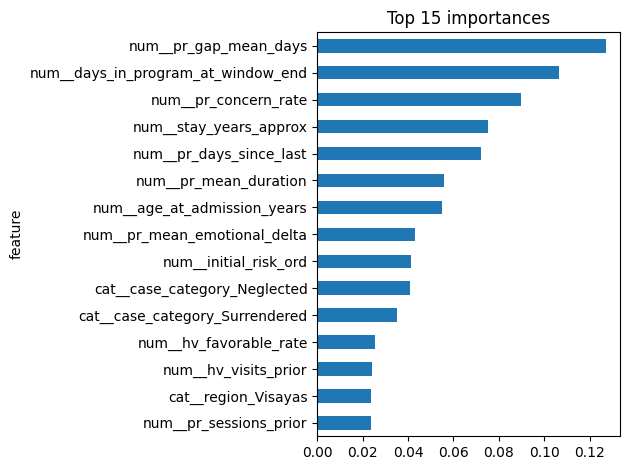

In [8]:
imp = feature_importance_dataframe(pipe)
if imp is not None:
    display(imp.head(15))
    plt.figure(figsize=(8, 5))
    imp.head(15).sort_values("importance").plot.barh(x="feature", y="importance", legend=False)
    plt.title("Top 15 importances")
    plt.tight_layout()
    plt.savefig(config.OUTPUTS_DIR / "fig_top_importances.png", dpi=120)
    plt.show()
else:
    print("Final model has no tree feature_importances_ (e.g. logistic).")

## 9. Export joblib + JSON artifacts for web app

In [9]:
info = export_from_trained_bundle(bundle, X, y, fe_meta)
print(json.dumps({k: str(v) if isinstance(v, Path) else v for k, v in info.items()}, indent=2))

{
  "metadata_path": "/Users/jooyoung/Downloads/intex2026/WinterIntex4-5/ml_pipeline/ml_pipeline_reintegration_effectiveness/serialized_models/reintegration_model_metadata.json",
  "pipeline_path": "/Users/jooyoung/Downloads/intex2026/WinterIntex4-5/ml_pipeline/ml_pipeline_reintegration_effectiveness/serialized_models/reintegration_predictive_pipeline.joblib",
  "test_metrics": {
    "accuracy": 0.6666666666666666,
    "precision": 0.5,
    "recall": 0.6,
    "f1": 0.5454545454545454,
    "confusion_matrix": [
      [
        7,
        3
      ],
      [
        2,
        3
      ]
    ],
    "roc_auc": 0.6000000000000001,
    "threshold": 0.5
  },
  "coef_path": "/Users/jooyoung/Downloads/intex2026/WinterIntex4-5/ml_pipeline/ml_pipeline_reintegration_effectiveness/outputs/explanatory_logistic_coefficients.csv"
}


## 10. Optional — re-run inference CLI\n\n`python -m ml_pipeline_reintegration_effectiveness.inference_example` from `ml_pipeline/`.